# Pipeline de Big Data — Visualización de Resultados
## Generación de Gráficas con matplotlib

**Alumno:** Victor Andres Aguila Lopez  
**Materia:** Big Data | UPIIT-IPN |  

En esta fase se generan las visualizaciones finales del pipeline a partir del dataset
`wildfires.csv` (1,880,465 registros) procesado en las fases anteriores con Hive y Pig.
Las gráficas sintetizan los hallazgos del análisis exploratorio y complementan las
métricas del modelo predictivo entrenado con Spark MLlib.

**Gráficas a generar:**
1. Top 10 causas de incendio por frecuencia
2. Tendencia anual de incendios y magnitud promedio (1992–2015)
3. Top 10 estados con mayor número de incendios
4. Distribución de incendios por clase de tamaño (NWCG)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('data/wildfires.csv')
print(f"Dataset cargado: {len(df):,} registros")
print(df.columns.tolist())

Dataset cargado: 1,880,465 registros
['FIRE_YEAR', 'DISCOVERY_DATE', 'DISCOVERY_DOY', 'STAT_CAUSE_DESCR', 'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'STATE', 'CONT_DATE', 'CONT_DOY', 'OWNER_DESCR']


### Dataset cargado correctamente
Se confirmaron **1,880,465 registros** con las 12 columnas del pipeline.
El estilo visual se configura globalmente: fondo limpio, sin bordes superiores/derechos,
fuente DejaVu Sans y tamaño de figura estándar 12×6 pulgadas para todas las gráficas.

---
### Gráfica 1 — Top 10 causas de incendio por frecuencia
Se agrupan los registros por `STAT_CAUSE_DESCR` y se toman las 10 categorías más frecuentes.
Las barras se ordenan de menor a mayor para facilitar la lectura horizontal.

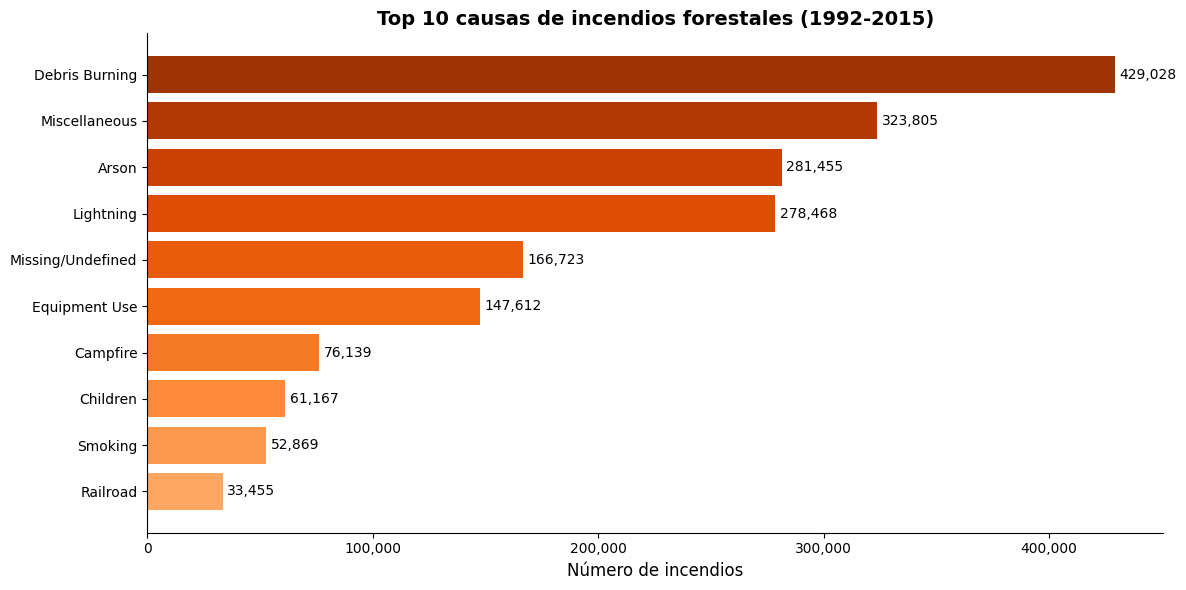

Grafica 1 guardada


In [2]:
causas = df['STAT_CAUSE_DESCR'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(causas.index, causas.values,
               color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(causas))))
ax.set_xlabel('Número de incendios', fontsize=12)
ax.set_title('Top 10 causas de incendios forestales (1992-2015)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, causas.values):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('visualizacion/grafica_1_causas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 1 guardada")

### Resultado Gráfica 1
**Debris Burning** lidera con 429,028 incendios (22.8% del total), seguido de
**Miscellaneous** (323,805) y **Arson** (281,455). Las causas de origen humano
explican más del 70% de todos los incendios registrados entre 1992 y 2015,
confirmando los resultados obtenidos previamente con las queries de Apache Hive.

---
### Gráfica 2 — Tendencia anual de incendios y magnitud promedio (1992–2015)
Se utiliza un eje doble (twin axis): barras para el conteo total de incendios por año
y línea para el promedio de acres quemados. Esto permite visualizar simultáneamente
la frecuencia y la magnitud de los eventos en cada año.

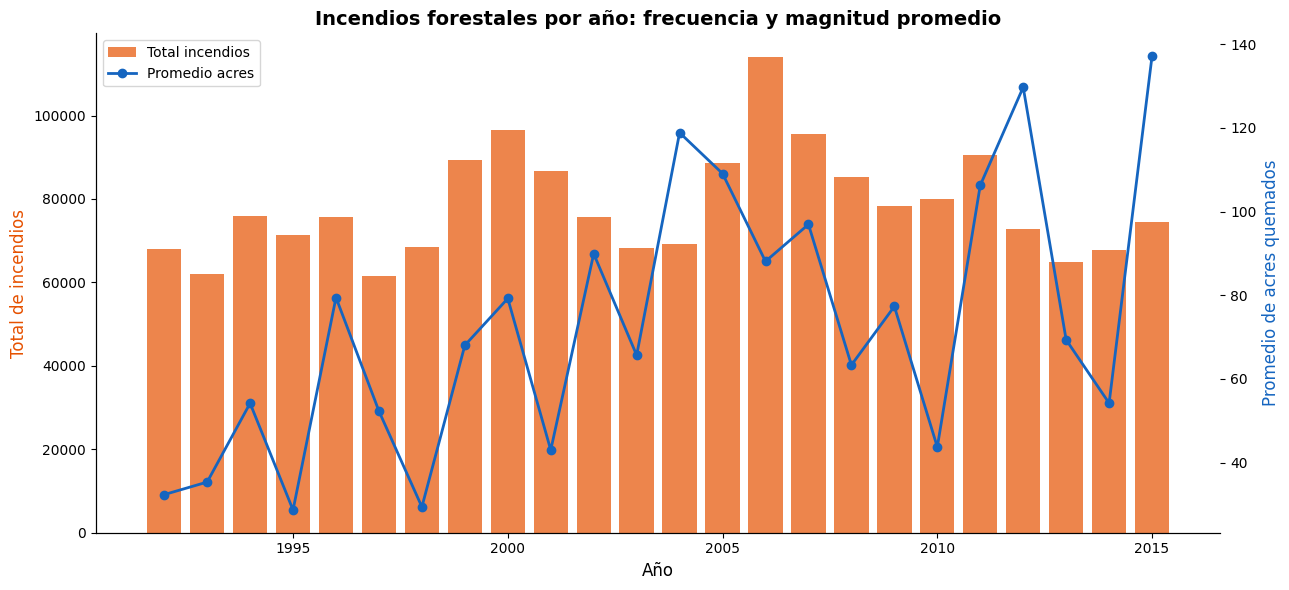

Grafica 2 guardada


In [3]:
por_año = df.groupby('FIRE_YEAR').agg(
    total=('FIRE_SIZE', 'count'),
    promedio_acres=('FIRE_SIZE', 'mean')
).reset_index()
por_año = por_año[por_año['FIRE_YEAR'].notna() & (por_año['FIRE_YEAR'] > 1990)]

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.bar(por_año['FIRE_YEAR'], por_año['total'],
        color='#E65100', alpha=0.7, label='Total incendios')
ax2.plot(por_año['FIRE_YEAR'], por_año['promedio_acres'],
         color='#1565C0', marker='o', linewidth=2, label='Promedio acres')

ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Total de incendios', fontsize=12, color='#E65100')
ax2.set_ylabel('Promedio de acres quemados', fontsize=12, color='#1565C0')
ax1.set_title('Incendios forestales por año: frecuencia y magnitud promedio', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('visualizacion/grafica_2_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 2 guardada")

### Resultado Gráfica 2
El año con mayor número de incendios fue **2006** con 114,004 eventos.
Sin embargo, los años con mayor magnitud promedio fueron **2015** (137.17 acres),
**2012** (129.72 acres) y **2004** (118.86 acres), lo que evidencia que frecuencia
y magnitud no siempre están correlacionadas — años con menos incendios pueden
concentrar eventos de mayor tamaño.

---
### Gráfica 3 — Top 10 estados con mayor número de incendios
Se agrupan los registros por `STATE` y se seleccionan los 10 estados con más eventos,
mostrando además el promedio de acres quemados como referencia de magnitud.

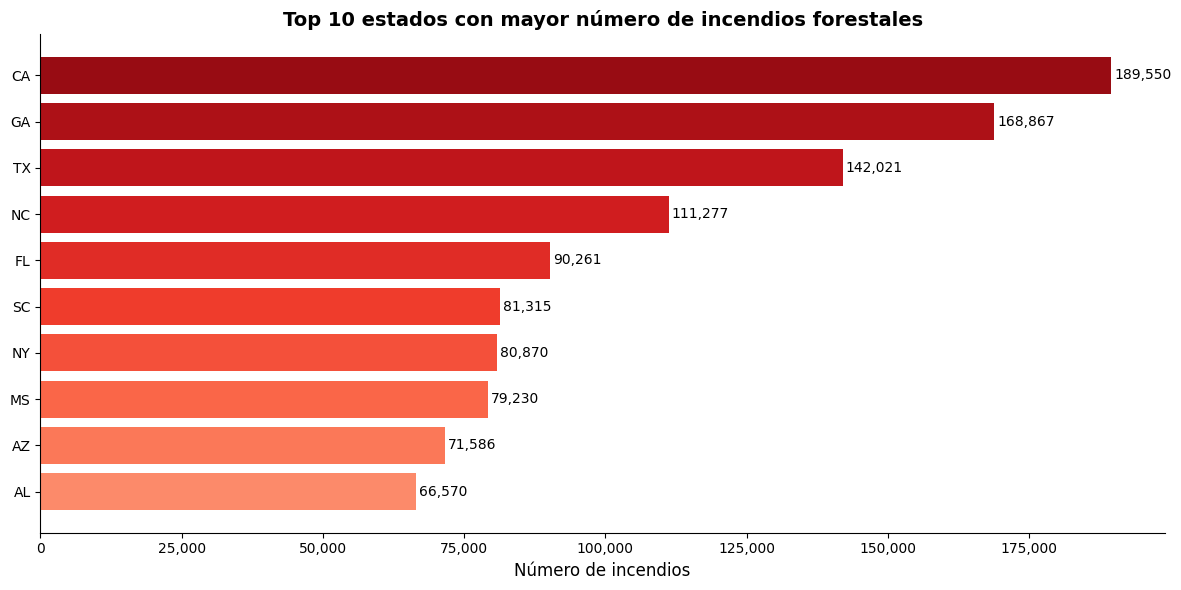

Grafica 3 guardada


In [4]:
estados = df.groupby('STATE').agg(
    total=('FIRE_SIZE', 'count'),
    promedio=('FIRE_SIZE', 'mean')
).nlargest(10, 'total').sort_values('total')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(estados.index, estados['total'],
               color=plt.cm.Reds(np.linspace(0.4, 0.9, len(estados))))
ax.set_xlabel('Número de incendios', fontsize=12)
ax.set_title('Top 10 estados con mayor número de incendios forestales', fontsize=14, fontweight='bold')
for bar, val in zip(bars, estados['total']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('visualizacion/grafica_3_estados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 3 guardada")

### Resultado Gráfica 3
**California (CA)** lidera con 189,550 incendios y un promedio de 67.24 acres por evento,
seguida de **Georgia (GA)** con 168,867 y **Texas (TX)** con 142,021.
Arizona presenta el mayor promedio de área quemada entre los 10 estados más afectados
(77.90 acres), reflejando la mayor extensión de sus incendios en terrenos federales remotos.

---
### Gráfica 4 — Distribución de incendios por clase de tamaño (NWCG)
La clasificación NWCG divide los incendios en 7 clases (A–G) según su área en acres.
Se usa una paleta de colores que va del verde (menor tamaño) al rojo oscuro (mayor tamaño)
para reforzar visualmente la escala de riesgo.

| Clase | Rango (acres) |
|-------|--------------|
| A | < 0.25 |
| B | 0.25 – 9.9 |
| C | 10 – 99 |
| D | 100 – 299 |
| E | 300 – 999 |
| F | 1,000 – 4,999 |
| G | ≥ 5,000 |

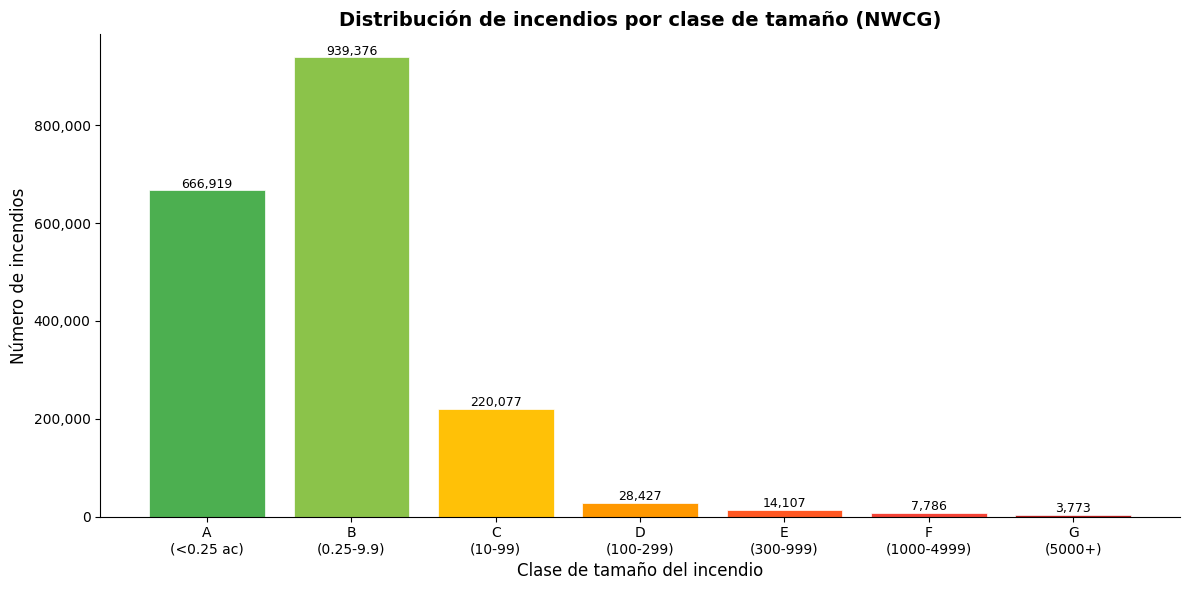

Grafica 4 guardada


In [5]:
clases = df['FIRE_SIZE_CLASS'].value_counts()
clases = clases[clases.index.isin(['A','B','C','D','E','F','G'])].sort_index()

descripciones = {
    'A': 'A\n(<0.25 ac)', 'B': 'B\n(0.25-9.9)', 'C': 'C\n(10-99)',
    'D': 'D\n(100-299)', 'E': 'E\n(300-999)', 'F': 'F\n(1000-4999)', 'G': 'G\n(5000+)'
}
etiquetas = [descripciones.get(c, c) for c in clases.index]
colores = ['#4CAF50','#8BC34A','#FFC107','#FF9800','#FF5722','#F44336','#B71C1C']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(etiquetas, clases.values, color=colores, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Clase de tamaño del incendio', fontsize=12)
ax.set_ylabel('Número de incendios', fontsize=12)
ax.set_title('Distribución de incendios por clase de tamaño (NWCG)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, clases.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('visualizacion/grafica_4_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 4 guardada")

### Resultado Gráfica 4
El **85% de los incendios** corresponde a las clases A (666,919) y B (939,376),
confirmando que la gran mayoría son eventos de pequeña magnitud contenidos rápidamente.
Sin embargo, los **3,773 incendios de clase G** (≥5,000 acres) representan el mayor
riesgo territorial con un promedio de 27,388 acres por evento — más de 11,000 hectáreas.
Esta distribución altamente sesgada explica en parte el RMSE elevado del modelo
predictivo (2,303.69 acres), dominado por estos eventos extremos.